# Fake News Detection: Data Loading, Cleaning & Encoding

This notebook handles the initial data pipeline:
1. Load the LIAR2 dataset
2. Explore and understand the data
3. Clean and preprocess text
4. Encode labels and prepare for modeling

## 1. Setup and Imports

In [1]:
# Standard library imports
import sys
import os

# Add src to path
sys.path.insert(0, '../src')

# Data processing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Custom processor
from data_processor import DataProcessor

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All imports successful")

✓ All imports successful


## 2. Initialize Data Processor

In [2]:
# Initialize processor
processor = DataProcessor()

print("Truthfulness labels:")
for idx, label in enumerate(processor.TRUTHFULNESS_LABELS):
    print(f"  {idx}: {label}")

Truthfulness labels:
  0: true
  1: mostly-true
  2: half-true
  3: barely-true
  4: false
  5: pants-fire


## 3. Load Data

**Note**: You need to download the LIAR2 dataset from: https://www.cs.ucsb.edu/~william/data/liar_plus_dataset.zip

Extract it and place the CSV file in the `data/` folder.

In [3]:
# Check available data files
data_dir = '../data'
if os.path.exists(data_dir):
    files = os.listdir(data_dir)
    print(f"Files in {data_dir}:")
    if files:
        for f in files:
            print(f"  - {f}")
    else:
        print("  (empty)")
else:
    print(f"Data directory not found: {data_dir}")

Files in ../data:
  - test.tsv
  - train.tsv
  - valid.tsv


In [4]:
data_file = '../data/train.tsv'


liar2_columns = [
    'id',
    'label',
    'statement',
    'subject',
    'speaker',
    'job_title',
    'state_info',
    'party_affiliation',
    'barely_true_count',
    'false_count',
    'half_true_count',
    'mostly_true_count',
    'pants_on_fire_count',
    'context',
    'justification'
]


if data_file.endswith('.tsv'):
    df = pd.read_csv(data_file, sep='\t', header=None, names=liar2_columns)
elif data_file.endswith('.csv'):
    df = pd.read_csv(data_file, header=None, names=liar2_columns)
else:
    raise ValueError("File must be .csv or .tsv")


print(f"Dataset shape: {df.shape}")
print(f"\nFirst few records:")
print(df.head())

Dataset shape: (10240, 15)

First few records:
           id        label                                          statement  \
0   2635.json        false  Says the Annies List political group supports ...   
1  10540.json    half-true  When did the decline of coal start? It started...   
2    324.json  mostly-true  Hillary Clinton agrees with John McCain "by vo...   
3   1123.json        false  Health care reform legislation is likely to ma...   
4   9028.json    half-true  The economic turnaround started at the end of ...   

                              subject         speaker             job_title  \
0                            abortion    dwayne-bohac  State representative   
1  energy,history,job-accomplishments  scott-surovell        State delegate   
2                      foreign-policy    barack-obama             President   
3                         health-care    blog-posting                   NaN   
4                        economy,jobs   charlie-crist                  

## 4. Data Exploration

In [5]:
# Basic info
print("Dataset Info:")
print(f"  Total records: {len(df)}")
print(f"  Columns: {df.columns.tolist()}")
print(f"\nMissing values:")
print(df.isnull().sum())

Dataset Info:
  Total records: 10240
  Columns: ['id', 'label', 'statement', 'subject', 'speaker', 'job_title', 'state_info', 'party_affiliation', 'barely_true_count', 'false_count', 'half_true_count', 'mostly_true_count', 'pants_on_fire_count', 'context', 'justification']

Missing values:
id                         0
label                      0
statement                  0
subject                    2
speaker                    2
job_title               2898
state_info              2210
party_affiliation          2
barely_true_count          2
false_count                2
half_true_count            2
mostly_true_count          2
pants_on_fire_count        2
context                  102
justification          10240
dtype: int64


In [6]:
# Check the actual column names and first few rows
print("Column names:")
print(df.columns.tolist())
print("\nFirst row:")
print(df.iloc[0])
print("\nData types:")
print(df.dtypes)

Column names:
['id', 'label', 'statement', 'subject', 'speaker', 'job_title', 'state_info', 'party_affiliation', 'barely_true_count', 'false_count', 'half_true_count', 'mostly_true_count', 'pants_on_fire_count', 'context', 'justification']

First row:
id                                                             2635.json
label                                                              false
statement              Says the Annies List political group supports ...
subject                                                         abortion
speaker                                                     dwayne-bohac
job_title                                           State representative
state_info                                                         Texas
party_affiliation                                             republican
barely_true_count                                                    0.0
false_count                                                          1.0
half_true_count   

Label Distribution:
label
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839
Name: count, dtype: int64


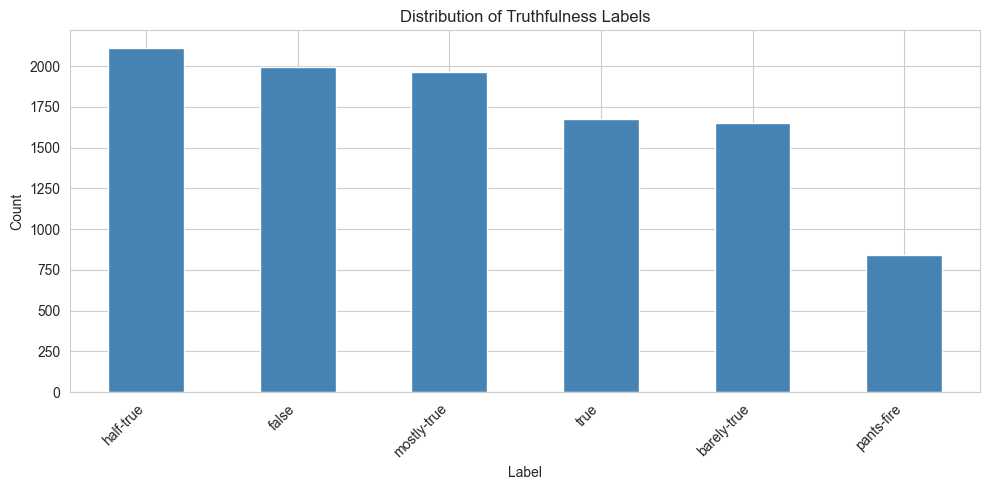


Label proportions:
label
half-true      0.206445
false          0.194824
mostly-true    0.191602
true           0.163672
barely-true    0.161523
pants-fire     0.081934
Name: count, dtype: float64


In [7]:
# Label distribution
label_counts = df['label'].value_counts()
print("Label Distribution:")
print(label_counts)

# Visualize
plt.figure(figsize=(10, 5))
label_counts.plot(kind='bar', color='steelblue')
plt.title('Distribution of Truthfulness Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nLabel proportions:")
print(label_counts / len(df))

In [8]:
# Text statistics
df['text_length'] = df['statement'].str.len()
df['word_count'] = df['statement'].str.split().str.len()

print("Text Statistics:")
print(f"  Average text length: {df['text_length'].mean():.1f} characters")
print(f"  Average word count: {df['word_count'].mean():.1f} words")
print(f"  Min/Max length: {df['text_length'].min()} / {df['text_length'].max()}")
print(f"  Min/Max words: {df['word_count'].min()} / {df['word_count'].max()}")

Text Statistics:
  Average text length: 106.9 characters
  Average word count: 18.0 words
  Min/Max length: 11 / 3192
  Min/Max words: 2 / 467


## 5. Data Cleaning

In [9]:
# Check unique labels in the dataset
print("Unique labels in dataset:")
unique_labels = df['label'].unique()
for label in sorted(unique_labels):
    count = (df['label'] == label).sum()
    print(f"  '{label}': {count} samples")

Unique labels in dataset:
  'barely-true': 1654 samples
  'false': 1995 samples
  'half-true': 2114 samples
  'mostly-true': 1962 samples
  'pants-fire': 839 samples
  'true': 1676 samples


In [10]:
# Apply cleaning pipeline
df_processed, encoded_labels = processor.process_pipeline(
    df.copy(),
    text_column='statement',
    label_column='label',
    remove_stops=True
)

print(f"\nProcessed dataset shape: {df_processed.shape}")
print(f"\nSample of cleaned text:")
for i in range(3):
    print(f"\n  Original: {df_processed['statement'].iloc[i]}")
    print(f"  Cleaned:  {df_processed['text_cleaned'].iloc[i]}")

INFO:data_processor:Starting data processing pipeline...
INFO:data_processor:Removed nulls: 10240 records remaining
INFO:data_processor:Removed empty texts: 10240 records remaining
INFO:data_processor:Encoded 10240 labels
INFO:data_processor:Data processing pipeline completed successfully



Processed dataset shape: (10240, 18)

Sample of cleaned text:

  Original: Says the Annies List political group supports third-trimester abortions on demand.
  Cleaned:  says annies list political group supports thirdtrimester abortions demand

  Original: When did the decline of coal start? It started when natural gas took off that started to begin in (President George W.) Bushs administration.
  Cleaned:  decline coal start started natural gas took started begin president george w bushs administration

  Original: Hillary Clinton agrees with John McCain "by voting to give George Bush the benefit of the doubt on Iran."
  Cleaned:  hillary clinton agrees john mccain voting give george bush benefit doubt iran


## 6. Text Encoding - Vocabulary

In [11]:
# Build vocabulary
vocab = processor.build_vocabulary(df_processed['text_cleaned'], min_freq=1)

print(f"\nVocabulary details:")
print(f"  Total unique words: {processor.vocab_size}")
print(f"\nSample vocabulary (first 20 words):")
for word, idx in list(vocab.items())[:20]:
    print(f"  {word}: {idx}")

INFO:data_processor:Building vocabulary...
INFO:data_processor:Vocabulary size: 13284



Vocabulary details:
  Total unique words: 13284

Sample vocabulary (first 20 words):
  says: 0
  percent: 1
  state: 2
  obama: 3
  tax: 4
  years: 5
  health: 6
  people: 7
  president: 8
  states: 9
  year: 10
  would: 11
  us: 12
  care: 13
  million: 14
  jobs: 15
  new: 16
  one: 17
  bill: 18
  texas: 19


## 7. Text Encoding - Sequences

In [12]:
# Convert texts to sequences
sequences = processor.texts_to_sequences(df_processed['text_cleaned'])

print(f"Number of sequences: {len(sequences)}")
print(f"\nSequence lengths:")
seq_lengths = [len(seq) for seq in sequences]
print(f"  Min: {min(seq_lengths)}, Max: {max(seq_lengths)}, Avg: {np.mean(seq_lengths):.1f}")

# Show example
print(f"\nExample sequence (first text):")
print(f"  Original text: {df_processed['text_cleaned'].iloc[0]}")
print(f"  Encoded sequence: {sequences[0]}")

Number of sequences: 10240

Sequence lengths:
  Min: 1, Max: 344, Avg: 11.1

Example sequence (first text):
  Original text: says annies list political group supports thirdtrimester abortions demand
  Encoded sequence: [0, 6997, 1001, 411, 495, 271, 5028, 460, 1450]


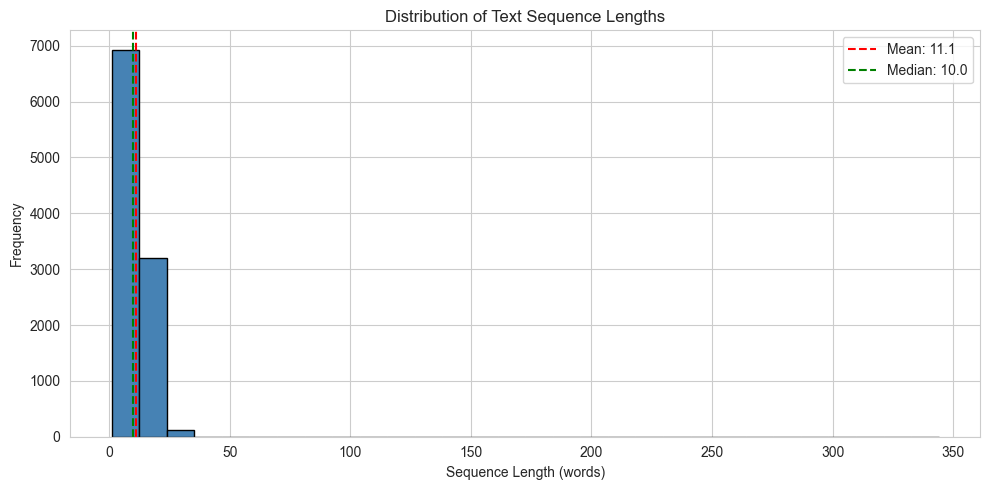

In [13]:
# Visualize sequence length distribution
plt.figure(figsize=(10, 5))
plt.hist(seq_lengths, bins=30, color='steelblue', edgecolor='black')
plt.axvline(np.mean(seq_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(seq_lengths):.1f}')
plt.axvline(np.median(seq_lengths), color='green', linestyle='--', label=f'Median: {np.median(seq_lengths):.1f}')
plt.xlabel('Sequence Length (words)')
plt.ylabel('Frequency')
plt.title('Distribution of Text Sequence Lengths')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Padding Sequences

In [17]:
# Pad sequences to fixed length
maxlen = 100  # Maximum sequence length
X = processor.pad_sequences(sequences, maxlen=maxlen)

print(f"Padded sequence shape: {X.shape}")
print(f"\nExample padded sequence:")
print(X[0])

Padded sequence shape: (10240, 100)

Example padded sequence:
[   0 6997 1001  411  495  271 5028  460 1450    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


## 9. Label Encoding

In [15]:
# Labels are already encoded from the pipeline
print(f"Encoded labels shape: {encoded_labels.shape}")
print(f"Unique label values: {np.unique(encoded_labels)}")
print(f"\nLabel mapping:")
for idx, label in enumerate(processor.TRUTHFULNESS_LABELS):
    count = np.sum(encoded_labels == idx)
    print(f"  {idx} ({label}): {count} samples")

# Store as output
y = encoded_labels

Encoded labels shape: (10240,)
Unique label values: [0 1 2 3 4 5]

Label mapping:
  0 (true): 1654 samples
  1 (mostly-true): 1995 samples
  2 (half-true): 2114 samples
  3 (barely-true): 1962 samples
  4 (false): 839 samples
  5 (pants-fire): 1676 samples


## 10. Summary and Save Processed Data

In [18]:
print("\n" + "="*60)
print("DATA PROCESSING SUMMARY")
print("="*60)
print(f"\nOriginal dataset: {len(df)} samples")
print(f"Processed dataset: {len(df_processed)} samples")
print(f"Removed: {len(df) - len(df_processed)} samples")
print(f"\nVocabulary size: {processor.vocab_size}")
print(f"Padded sequence shape: {X.shape}")
print(f"Encoded labels shape: {y.shape}")
print(f"\nNumber of classes: {len(processor.TRUTHFULNESS_LABELS)}")
print(f"\nData ready for model training!")
print("="*60)


DATA PROCESSING SUMMARY

Original dataset: 10240 samples
Processed dataset: 10240 samples
Removed: 0 samples

Vocabulary size: 13284
Padded sequence shape: (10240, 100)
Encoded labels shape: (10240,)

Number of classes: 6

Data ready for model training!


## 11. Optional: Save Processed Data

In [19]:
# Save processed data for later use
import pickle

artifacts_dir = '../artifacts'
os.makedirs(artifacts_dir, exist_ok=True)

# Save processed dataframe
df_processed.to_csv(f'{artifacts_dir}/processed_data.csv', index=False)

# Save encoded data
np.savez(f'{artifacts_dir}/encoded_data.npz', X=X, y=y)

# Save processor state
with open(f'{artifacts_dir}/processor.pkl', 'wb') as f:
    pickle.dump(processor, f)

print(f"✓ Saved processed data to {artifacts_dir}")
print(f"  - processed_data.csv")
print(f"  - encoded_data.npz")
print(f"  - processor.pkl")

✓ Saved processed data to ../artifacts
  - processed_data.csv
  - encoded_data.npz
  - processor.pkl
